# Testing norm of gemma (HookedSAETransformer) across layers

In [1]:
# SAE Hooks Verification Notebook

import torch as t
from transformers import AutoTokenizer, AutoModelForCausalLM
from sae_lens import HookedSAETransformer, SAE

t.set_grad_enabled(False)

# Load model and SAE
def load_model_and_sae(layer, device):
    model_name = "google/gemma-2-2b-it"

    model = HookedSAETransformer.from_pretrained(model_name, device=device)
    sae, _, _ = SAE.from_pretrained(
        release="gemma-scope-2b-pt-res-canonical",
        sae_id=f"layer_{layer}/width_16k/canonical",
        device=str(device),
    )
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    sae.use_error_term = False
    return model, sae, tokenizer

# Setup

layer = 5
device = t.device("cuda" if t.cuda.is_available() else "cpu")
model, sae, tokenizer = load_model_and_sae(layer, device)


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded pretrained model google/gemma-2-2b-it into HookedTransformer


In [4]:
prompt = "15+20= "
# Tokenize
tokens = tokenizer([prompt], return_tensors="pt", add_special_tokens=True).to(device)
print(f"Tokenized shape: {tokens.input_ids.shape}")
logits, cache = model.run_with_cache(tokens.input_ids, )
print(f"Logits shape: {logits.shape}")
print(f"Cache keys: {list(cache.keys())}")
print(f"Cache layer 0 shape: {cache['blocks.0.hook_resid_post'].shape}")

Tokenized shape: torch.Size([1, 8])
Logits shape: torch.Size([1, 8, 256000])
Cache keys: ['hook_embed', 'blocks.0.hook_resid_pre', 'blocks.0.ln1.hook_scale', 'blocks.0.ln1.hook_normalized', 'blocks.0.attn.hook_q', 'blocks.0.attn.hook_k', 'blocks.0.attn.hook_v', 'blocks.0.attn.hook_rot_q', 'blocks.0.attn.hook_rot_k', 'blocks.0.attn.hook_attn_scores', 'blocks.0.attn.hook_pattern', 'blocks.0.attn.hook_z', 'blocks.0.ln1_post.hook_scale', 'blocks.0.ln1_post.hook_normalized', 'blocks.0.hook_attn_out', 'blocks.0.hook_resid_mid', 'blocks.0.ln2.hook_scale', 'blocks.0.ln2.hook_normalized', 'blocks.0.mlp.hook_pre', 'blocks.0.mlp.hook_pre_linear', 'blocks.0.mlp.hook_post', 'blocks.0.ln2_post.hook_scale', 'blocks.0.ln2_post.hook_normalized', 'blocks.0.hook_mlp_out', 'blocks.0.hook_resid_post', 'blocks.1.hook_resid_pre', 'blocks.1.ln1.hook_scale', 'blocks.1.ln1.hook_normalized', 'blocks.1.attn.hook_q', 'blocks.1.attn.hook_k', 'blocks.1.attn.hook_v', 'blocks.1.attn.hook_rot_q', 'blocks.1.attn.hook_ro

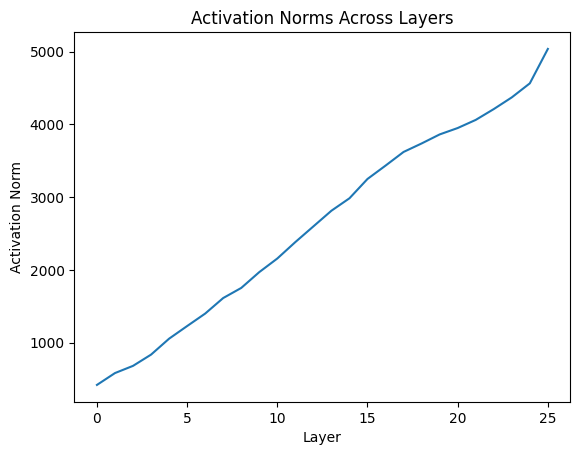

In [5]:
# calculate the norm of the activations at each layer
# Use the cache from the previous cell instead of output_no_abl.hidden_states
layer_keys = [key for key in cache.keys() if 'hook_resid_post' in key]
layer_keys.sort(key=lambda x: int(x.split('.')[1]))  # Sort by layer number
activation_norms = [cache[key].norm().item() for key in layer_keys]

import matplotlib.pyplot as plt
plt.plot(list(range(len(activation_norms))), activation_norms)
plt.xlabel("Layer")
plt.ylabel("Activation Norm")
plt.title("Activation Norms Across Layers")
plt.show()

In [6]:
# Load dataset and process multiple examples
import numpy as np
from tqdm import tqdm

def load_dataset_local(file_path, max_examples=1000, max_tokens=10):
    """Load dataset and truncate examples to max_tokens"""
    with open(file_path, 'r') as f:
        lines = f.readlines()[:max_examples]
    
    examples = []
    for line in lines:
        line = line.strip()
        # Tokenize and truncate to max_tokens
        tokens = tokenizer(line, return_tensors="pt", add_special_tokens=True, truncation=True)
        if tokens.input_ids.shape[1] > max_tokens:
            tokens.input_ids = tokens.input_ids[:, :max_tokens]
            tokens.attention_mask = tokens.attention_mask[:, :max_tokens]
        
        # Convert to dict and keep on CPU for storage
        token_dict = {k: v.cpu() for k, v in tokens.items()}
        examples.append(token_dict)
    
    return examples

# Load 1000 examples from addition dataset
dataset_path = "/home/ammar/gemma_scope_math/data/addition.txt"
examples = load_dataset_local(dataset_path, max_examples=1000, max_tokens=10)
print(f"Loaded {len(examples)} examples")

# Process all examples and collect activation norms
all_activation_norms = []

print("Processing examples...")
for i, tokens in enumerate(tqdm(examples)):
    # Move tokens to device properly
    if isinstance(tokens, dict):
        tokens = {k: v.to(device) for k, v in tokens.items()}
        input_ids = tokens['input_ids']
    else:
        tokens = tokens.to(device)
        input_ids = tokens.input_ids
    
    with t.no_grad():
        # Use run_with_cache instead of output_hidden_states=True
        logits, cache = model.run_with_cache(input_ids)
        
    # Calculate norm for each layer using cache
    layer_keys = [key for key in cache.keys() if 'hook_resid_post' in key]
    layer_keys.sort(key=lambda x: int(x.split('.')[1]))  # Sort by layer number
    layer_norms = [cache[key].norm().item() for key in layer_keys]
    all_activation_norms.append(layer_norms)

# Convert to numpy array for easier manipulation
all_activation_norms = np.array(all_activation_norms)
print(f"Shape of activation norms: {all_activation_norms.shape}")
print(f"(examples, layers): ({all_activation_norms.shape[0]}, {all_activation_norms.shape[1]})")
# Note: No need to exclude final layer since we're using residual stream activations

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Loaded 1000 examples
Processing examples...


100%|██████████| 1000/1000 [01:49<00:00,  9.13it/s]

Shape of activation norms: (1000, 26)
(examples, layers): (1000, 26)


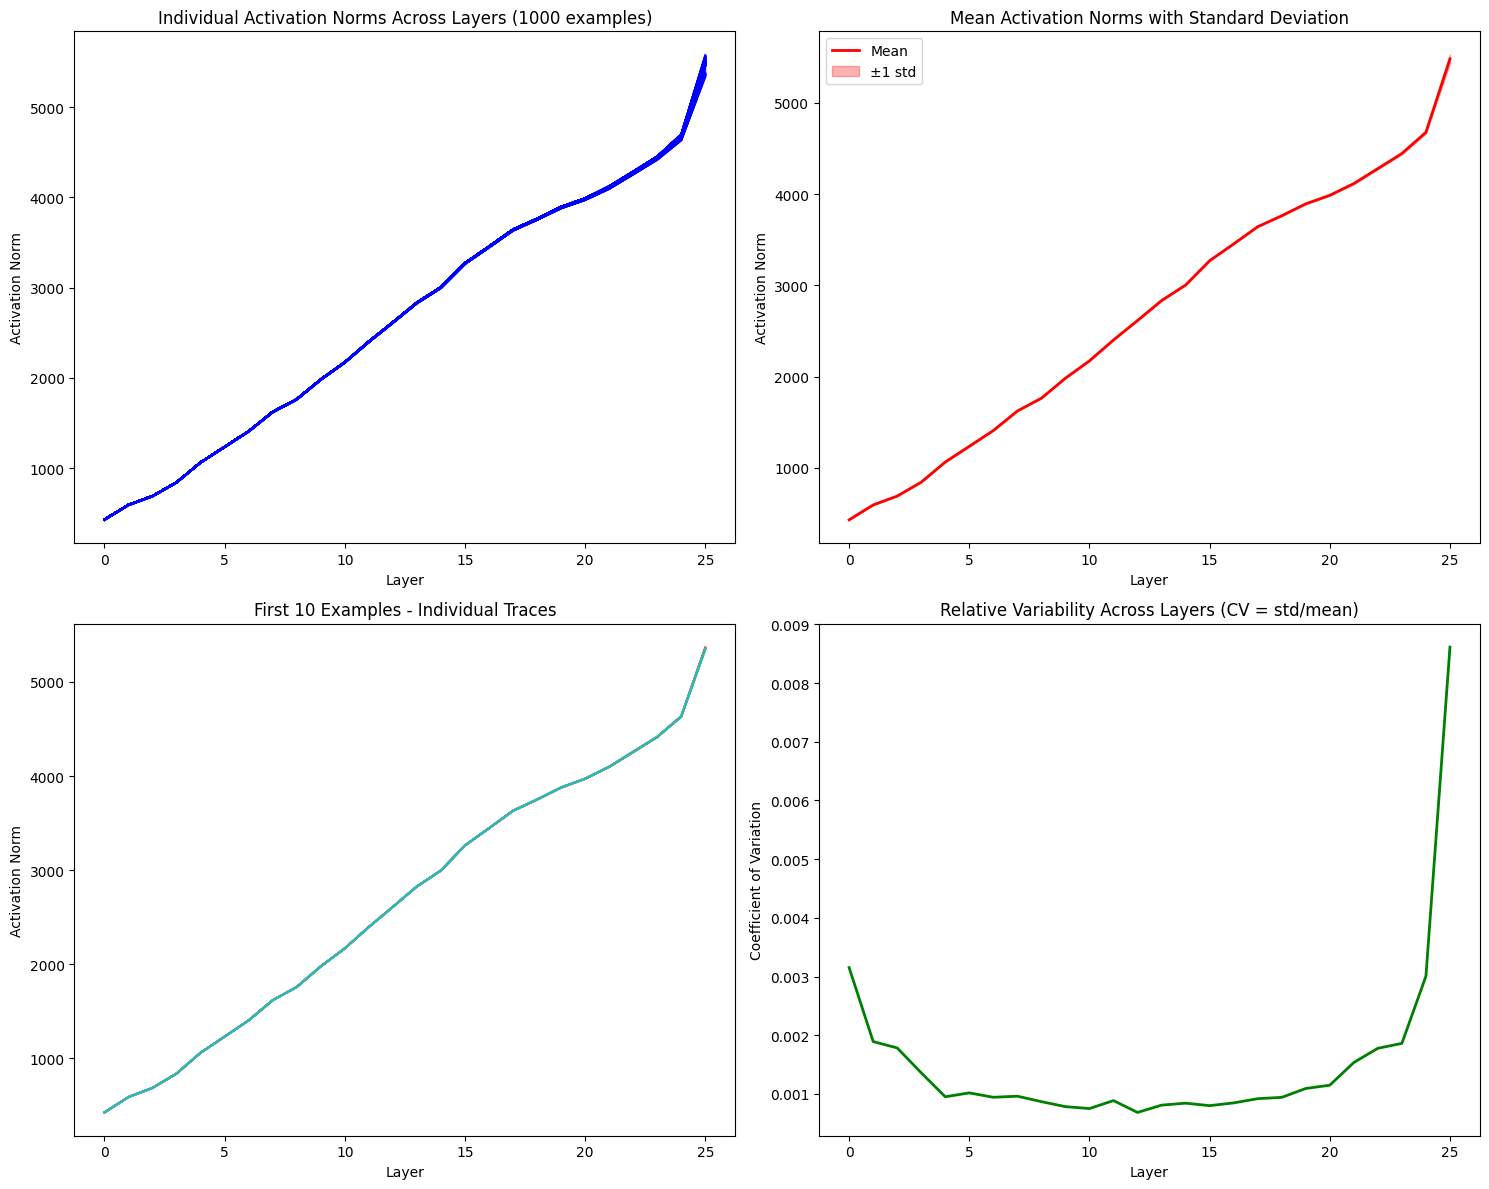

\nStatistics:
Mean activation norm across all layers and examples: 2679.4415
Overall standard deviation: 1411.3785
Overall coefficient of variation: 0.5267
\nPer-layer statistics:
Layer  0: mean=429.7221, std=  1.3545, cv=0.0032
Layer  1: mean=592.9364, std=  1.1217, cv=0.0019
Layer  2: mean=690.1622, std=  1.2309, cv=0.0018
Layer  3: mean=842.6997, std=  1.1451, cv=0.0014
Layer  4: mean=1063.0143, std=  1.0111, cv=0.0010
Layer  5: mean=1235.5930, std=  1.2566, cv=0.0010
Layer  6: mean=1408.4870, std=  1.3274, cv=0.0009
Layer  7: mean=1622.7946, std=  1.5590, cv=0.0010
Layer  8: mean=1762.8533, std=  1.5303, cv=0.0009
Layer  9: mean=1982.2455, std=  1.5515, cv=0.0008
Layer 10: mean=2172.8485, std=  1.6300, cv=0.0008
Layer 11: mean=2401.4112, std=  2.1278, cv=0.0009
Layer 12: mean=2614.5162, std=  1.7876, cv=0.0007
Layer 13: mean=2832.9789, std=  2.2905, cv=0.0008
Layer 14: mean=3003.3603, std=  2.5288, cv=0.0008
Layer 15: mean=3270.0975, std=  2.6145, cv=0.0008
Layer 16: mean=3454.2845

In [7]:
# Create comprehensive plots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: All individual traces (semi-transparent)
axes[0, 0].plot(all_activation_norms.T, alpha=0.1, color='blue')
axes[0, 0].set_xlabel("Layer")
axes[0, 0].set_ylabel("Activation Norm")
axes[0, 0].set_title("Individual Activation Norms Across Layers (1000 examples)")

# Plot 2: Mean and std
mean_norms = np.mean(all_activation_norms, axis=0)
std_norms = np.std(all_activation_norms, axis=0)
layers = np.arange(len(mean_norms))

axes[0, 1].plot(layers, mean_norms, 'r-', linewidth=2, label='Mean')
axes[0, 1].fill_between(layers, mean_norms - std_norms, mean_norms + std_norms, 
                        alpha=0.3, color='red', label='±1 std')
axes[0, 1].set_xlabel("Layer")
axes[0, 1].set_ylabel("Activation Norm")
axes[0, 1].set_title("Mean Activation Norms with Standard Deviation")
axes[0, 1].legend()

# Plot 3: First few examples for comparison
axes[1, 0].plot(all_activation_norms[:10].T, linewidth=1.5)
axes[1, 0].set_xlabel("Layer")
axes[1, 0].set_ylabel("Activation Norm")
axes[1, 0].set_title("First 10 Examples - Individual Traces")

# Plot 4: Coefficient of Variation (std/mean) to show relative variability
cv = std_norms / mean_norms
axes[1, 1].plot(layers, cv, 'g-', linewidth=2)
axes[1, 1].set_xlabel("Layer")
axes[1, 1].set_ylabel("Coefficient of Variation")
axes[1, 1].set_title("Relative Variability Across Layers (CV = std/mean)")

plt.tight_layout()
plt.show()

# Print some statistics
print("\\nStatistics:")
print(f"Mean activation norm across all layers and examples: {np.mean(all_activation_norms):.4f}")
print(f"Overall standard deviation: {np.std(all_activation_norms):.4f}")
print(f"Overall coefficient of variation: {np.std(all_activation_norms)/np.mean(all_activation_norms):.4f}")

print("\\nPer-layer statistics:")
for i, (mean_norm, std_norm) in enumerate(zip(mean_norms, std_norms)):
    print(f"Layer {i:2d}: mean={mean_norm:8.4f}, std={std_norm:8.4f}, cv={std_norm/mean_norm:.4f}")

Processing addition dataset...


addition:   0%|          | 0/200 [00:00<?, ?it/s]

addition: 100%|██████████| 200/200 [00:21<00:00,  9.46it/s]



Processing subtraction dataset...


subtraction: 100%|██████████| 200/200 [00:21<00:00,  9.50it/s]



Processing random_addition dataset...


random_addition: 100%|██████████| 200/200 [00:20<00:00,  9.53it/s]



Processing random_subtraction dataset...


random_subtraction: 100%|██████████| 200/200 [00:21<00:00,  9.47it/s]



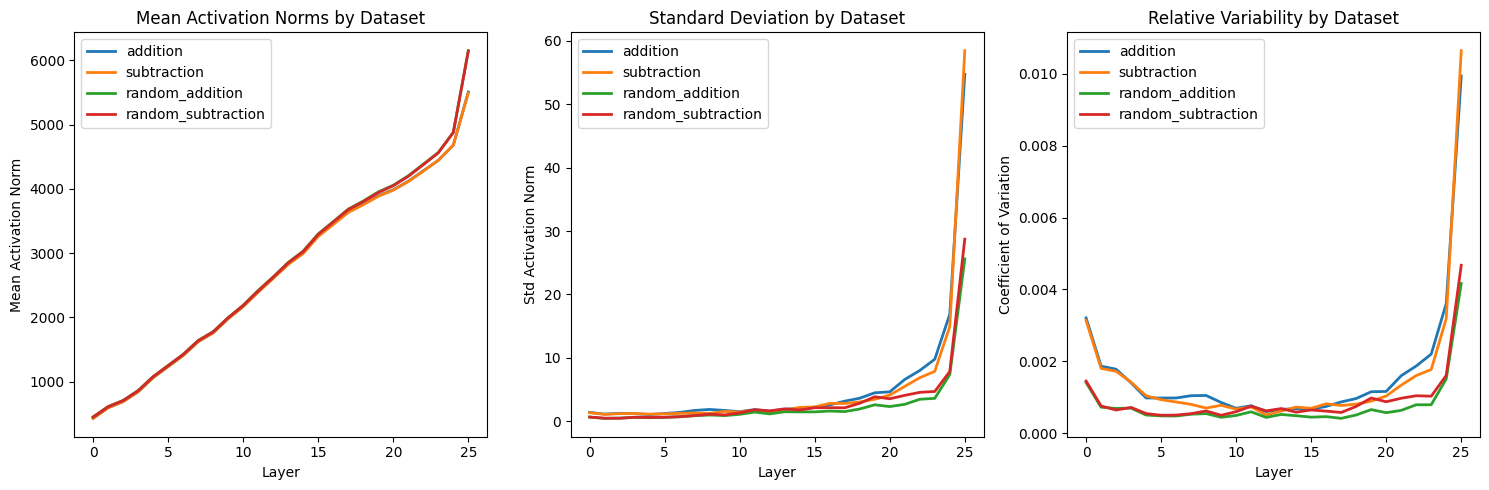

In [8]:
# Compare activation norms across different datasets
def compare_datasets():
    datasets = {
        'addition': '/home/ammar/gemma_scope_math/data/addition.txt',
        'subtraction': '/home/ammar/gemma_scope_math/data/subtraction.txt',
        'random_addition': '/home/ammar/gemma_scope_math/data/random_addition.txt',
        'random_subtraction': '/home/ammar/gemma_scope_math/data/random_subtraction.txt'
    }
    
    dataset_norms = {}
    
    for name, path in datasets.items():
        print(f"Processing {name} dataset...")
        examples = load_dataset_local(path, max_examples=200, max_tokens=10)  # Smaller sample for comparison
        
        norms = []
        for tokens in tqdm(examples, desc=name):
            # Move tokens to device properly
            if isinstance(tokens, dict):
                tokens = {k: v.to(device) for k, v in tokens.items()}
                input_ids = tokens['input_ids']
            else:
                tokens = tokens.to(device)
                input_ids = tokens.input_ids
            
            with t.no_grad():
                # Use run_with_cache instead of output_hidden_states=True
                logits, cache = model.run_with_cache(input_ids)
                
            # Calculate norm for each layer using cache
            layer_keys = [key for key in cache.keys() if 'hook_resid_post' in key]
            layer_keys.sort(key=lambda x: int(x.split('.')[1]))  # Sort by layer number
            layer_norms = [cache[key].norm().item() for key in layer_keys]
            norms.append(layer_norms)
        
        dataset_norms[name] = np.array(norms)
    
    # Plot comparison
    plt.figure(figsize=(15, 5))
    
    # Plot 1: Mean norms comparison
    plt.subplot(1, 3, 1)
    for name, norms in dataset_norms.items():
        mean_norms = np.mean(norms, axis=0)
        plt.plot(mean_norms, label=name, linewidth=2)
    plt.xlabel("Layer")
    plt.ylabel("Mean Activation Norm")
    plt.title("Mean Activation Norms by Dataset")
    plt.legend()
    
    # Plot 2: Standard deviation comparison
    plt.subplot(1, 3, 2)
    for name, norms in dataset_norms.items():
        std_norms = np.std(norms, axis=0)
        plt.plot(std_norms, label=name, linewidth=2)
    plt.xlabel("Layer")
    plt.ylabel("Std Activation Norm")
    plt.title("Standard Deviation by Dataset")
    plt.legend()
    
    # Plot 3: Coefficient of variation comparison
    plt.subplot(1, 3, 3)
    for name, norms in dataset_norms.items():
        mean_norms = np.mean(norms, axis=0)
        std_norms = np.std(norms, axis=0)
        cv = std_norms / mean_norms
        plt.plot(cv, label=name, linewidth=2)
    plt.xlabel("Layer")
    plt.ylabel("Coefficient of Variation")
    plt.title("Relative Variability by Dataset")
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    return dataset_norms

# Run the comparison
dataset_norms = compare_datasets()

In [9]:
# Load and process text dataset for norm analysis
from datasets import load_dataset

def load_text_dataset(dataset_name="openwebtext", split="train", max_examples=1000, max_tokens=10):
    """Load a text dataset and truncate examples to max_tokens"""
    print(f"Loading {dataset_name} dataset...")
    
    # Load dataset from HuggingFace
    if dataset_name == "wikitext":
        dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split=split, streaming=True)
        text_field = "text"
    elif dataset_name == "openwebtext":
        dataset = load_dataset("openwebtext", split=split, streaming=True)
        text_field = "text"
    elif dataset_name == "c4":
        dataset = load_dataset("c4", "en", split=split, streaming=True)
        text_field = "text"
    elif dataset_name == "bookcorpus":
        dataset = load_dataset("bookcorpus", split=split, streaming=True)
        text_field = "text"
    else:
        # Default to a simple text dataset
        dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split=split, streaming=True)
        text_field = "text"
    
    examples = []
    count = 0
    
    for item in dataset:
        if count >= max_examples:
            break
            
        text = item[text_field].strip()
        if len(text) < 10:  # Skip very short texts
            continue
            
        # Tokenize and truncate to max_tokens
        tokens = tokenizer(text, return_tensors="pt", add_special_tokens=True, truncation=True)
        if tokens.input_ids.shape[1] > max_tokens:
            tokens.input_ids = tokens.input_ids[:, :max_tokens]
            tokens.attention_mask = tokens.attention_mask[:, :max_tokens]
        elif tokens.input_ids.shape[1] < 3:  # Skip very short tokenized sequences
            continue
        
        # Ensure tokens are on CPU for storage (will move to device during processing)
        tokens = {k: v.cpu() for k, v in tokens.items()}
        examples.append(tokens)
        count += 1
        
        if count % 100 == 0:
            print(f"Loaded {count} text examples...")
    
    print(f"Finished loading {len(examples)} text examples")
    return examples

# Load text dataset (using WikiText-2)
print("Loading text dataset for comparison...")
text_examples = load_text_dataset("wikitext", max_examples=1000, max_tokens=10)

# Process text examples and collect activation norms
text_activation_norms = []

print("Processing text examples...")
for i, tokens in enumerate(tqdm(text_examples, desc="Text processing")):
    # Ensure tokens are properly moved to device
    if isinstance(tokens, dict):
        tokens = {k: v.to(device) for k, v in tokens.items()}
        input_ids = tokens['input_ids']
    else:
        tokens = tokens.to(device)
        input_ids = tokens.input_ids
    
    with t.no_grad():
        # Use run_with_cache instead of output_hidden_states=True
        logits, cache = model.run_with_cache(input_ids)
        
    # Calculate norm for each layer using cache
    layer_keys = [key for key in cache.keys() if 'hook_resid_post' in key]
    layer_keys.sort(key=lambda x: int(x.split('.')[1]))  # Sort by layer number
    layer_norms = [cache[key].norm().item() for key in layer_keys]
    text_activation_norms.append(layer_norms)

# Convert to numpy array
text_activation_norms = np.array(text_activation_norms)
print(f"Text dataset shape: {text_activation_norms.shape}")


Loading text dataset for comparison...
Loading wikitext dataset...
Loaded 100 text examples...
Loaded 200 text examples...
Loaded 300 text examples...
Loaded 400 text examples...
Loaded 500 text examples...
Loaded 100 text examples...
Loaded 200 text examples...
Loaded 300 text examples...
Loaded 400 text examples...
Loaded 500 text examples...
Loaded 600 text examples...
Loaded 700 text examples...
Loaded 800 text examples...
Loaded 900 text examples...
Loaded 1000 text examples...
Finished loading 1000 text examples
Processing text examples...
Loaded 600 text examples...
Loaded 700 text examples...
Loaded 800 text examples...
Loaded 900 text examples...
Loaded 1000 text examples...
Finished loading 1000 text examples
Processing text examples...


Text processing: 100%|██████████| 1000/1000 [02:49<00:00,  5.89it/s]

Text dataset shape: (1000, 26)


=== MATH vs TEXT DATASET COMPARISON ===



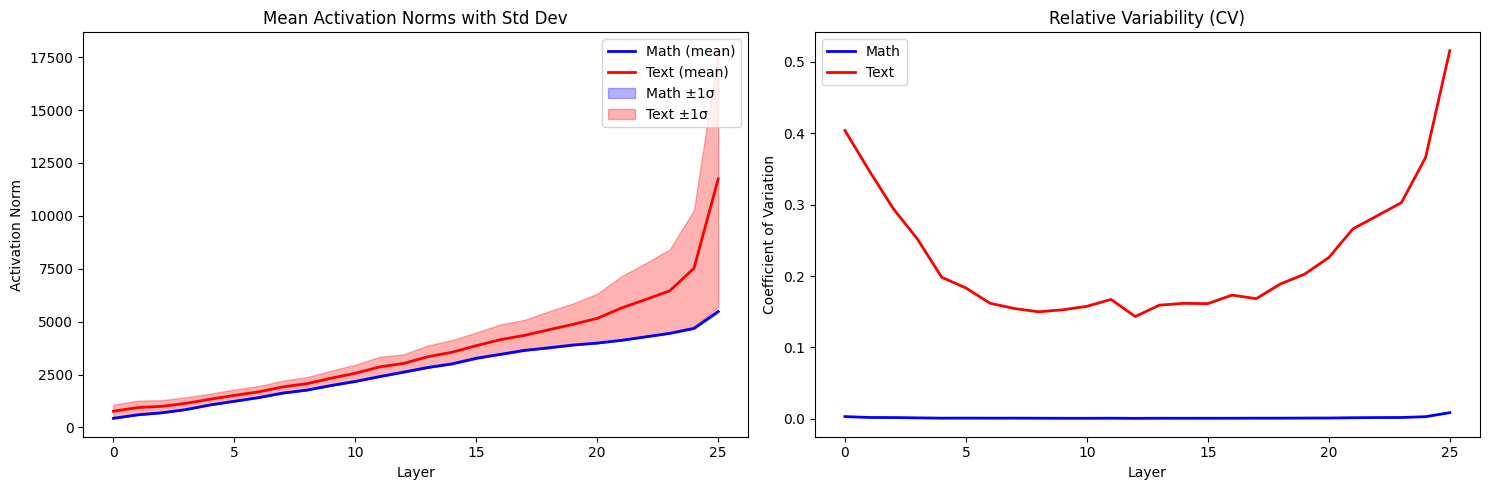

Dataset sizes:
  Math dataset: 1000 examples
  Text dataset: 1000 examples

Overall statistics:
  Math - Mean: 2679.4415, Std: 1411.3785
  Text - Mean: 3631.6162, Std: 2882.1777

Mean coefficient of variation across layers:
  Math: 0.0015
  Text: 0.2286

Layer-wise t-test results (first 5 layers):
  Layer 0: t=-34.406, p=0.000000 ***
  Layer 1: t=-33.286, p=0.000000 ***
  Layer 2: t=-32.868, p=0.000000 ***
  Layer 3: t=-32.622, p=0.000000 ***
  Layer 4: t=-32.208, p=0.000000 ***


In [10]:
# Compare math vs text dataset activation norms
def compare_math_vs_text():
    """Compare activation norms between math and text datasets"""
    
    print("=== MATH vs TEXT DATASET COMPARISON ===\n")
    
    # Calculate statistics for both datasets
    math_mean = np.mean(all_activation_norms, axis=0)
    math_std = np.std(all_activation_norms, axis=0)
    math_cv = math_std / math_mean
    
    text_mean = np.mean(text_activation_norms, axis=0)
    text_std = np.std(text_activation_norms, axis=0)
    text_cv = text_std / text_mean
    
    # Create comparison plots
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot 1: Mean comparison
    axes[0].plot(math_mean, 'b-', linewidth=2, label='Math (mean)')
    axes[0].plot(text_mean, 'r-', linewidth=2, label='Text (mean)')
    axes[0].fill_between(range(len(math_mean)), math_mean - math_std, math_mean + math_std, 
                           alpha=0.3, color='blue', label='Math ±1σ')
    axes[0].fill_between(range(len(text_mean)), text_mean - text_std, text_mean + text_std, 
                           alpha=0.3, color='red', label='Text ±1σ')
    axes[0].set_xlabel("Layer")
    axes[0].set_ylabel("Activation Norm")
    axes[0].set_title("Mean Activation Norms with Std Dev")
    axes[0].legend()
    
    # Plot 2: Coefficient of Variation comparison
    axes[1].plot(math_cv, 'b-', linewidth=2, label='Math')
    axes[1].plot(text_cv, 'r-', linewidth=2, label='Text')
    axes[1].set_xlabel("Layer")
    axes[1].set_ylabel("Coefficient of Variation")
    axes[1].set_title("Relative Variability (CV)")
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print statistical comparison
    print(f"Dataset sizes:")
    print(f"  Math dataset: {all_activation_norms.shape[0]} examples")
    print(f"  Text dataset: {text_activation_norms.shape[0]} examples")
    
    print(f"\nOverall statistics:")
    print(f"  Math - Mean: {np.mean(all_activation_norms):.4f}, Std: {np.std(all_activation_norms):.4f}")
    print(f"  Text - Mean: {np.mean(text_activation_norms):.4f}, Std: {np.std(text_activation_norms):.4f}")
    
    print(f"\nMean coefficient of variation across layers:")
    print(f"  Math: {np.mean(math_cv):.4f}")
    print(f"  Text: {np.mean(text_cv):.4f}")
    
    # Statistical test for difference in means
    from scipy.stats import ttest_ind
    
    print(f"\nLayer-wise t-test results (first 5 layers):")
    for i in range(min(5, len(math_mean))):
        t_stat, p_val = ttest_ind(all_activation_norms[:, i], text_activation_norms[:, i])
        significance = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
        print(f"  Layer {i}: t={t_stat:.3f}, p={p_val:.6f} {significance}")
    
    return {
        'math_stats': {'mean': math_mean, 'std': math_std, 'cv': math_cv},
        'text_stats': {'mean': text_mean, 'std': text_std, 'cv': text_cv}
    }

# Run the comparison
comparison_results = compare_math_vs_text()

# Testing norm of gemma scope (SAEs) across layers